In [3]:
import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as sns  
from matplotlib_venn import venn2  
from scipy import stats  
import os  
from matplotlib.lines import Line2D  
from matplotlib import rcParams  

# Create output directory for plots  
output_dir = '../comparison/vglut2_vs_vgat'  
if not os.path.exists(output_dir):  
    os.makedirs(output_dir)  

In [4]:
rcParams['font.family'] = 'sans-serif'  
rcParams['font.sans-serif'] = ['Arial']  
rcParams['font.size'] = 8
rcParams['axes.linewidth'] = 0.8  
rcParams['xtick.major.width'] = 0.8  
rcParams['ytick.major.width'] = 0.8  
rcParams['xtick.major.size'] = 3  
rcParams['ytick.major.size'] = 3  
rcParams['pdf.fonttype'] = 42  # Ensures text is editable in AI  
rcParams['ps.fonttype'] = 42  
rcParams['svg.fonttype'] = 'none'  
rcParams['figure.dpi'] = 300  

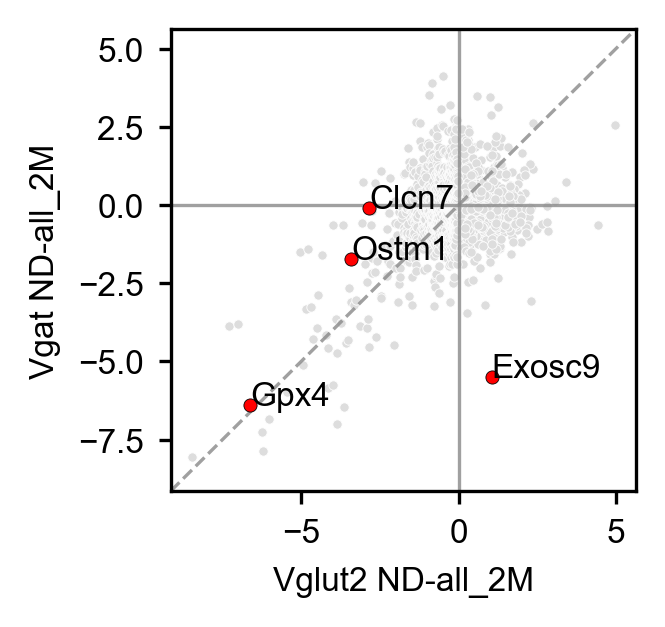

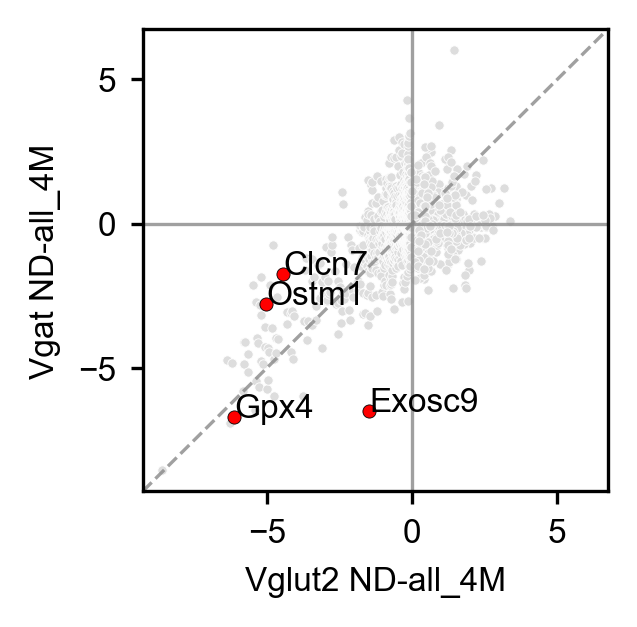

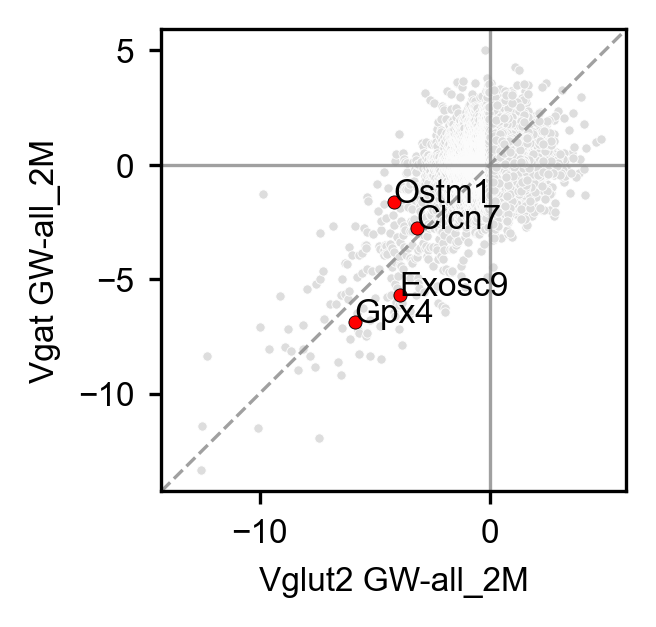

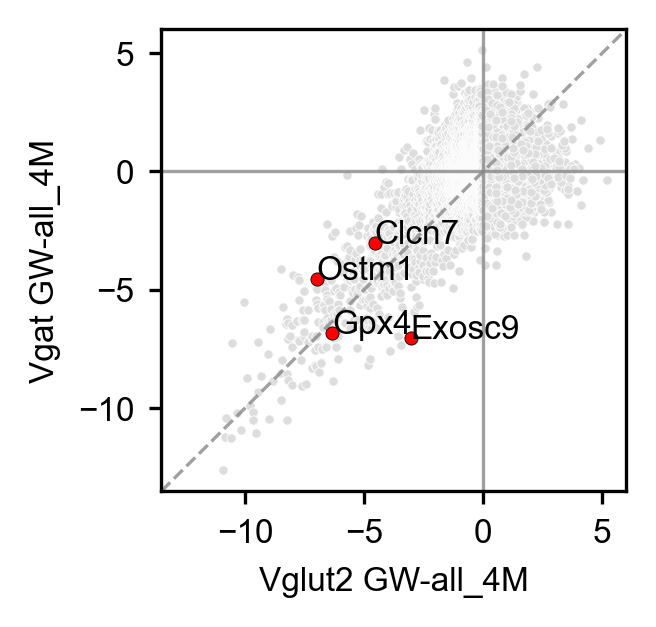

In [5]:
# Generate example data for two screens  
libraries = ['ND-all_2M', 'ND-all_4M', 'GW-all_2M', 'GW-all_4M']
# libraries = ['ND_2M', 'ND_4M']
for library in libraries:
    vglut2_file = f'../new_mageck/Vglut2-{library}/Vglut2-{library}.gene_summary.txt'
    df = pd.read_csv(vglut2_file, sep='\t', index_col=0)
    # gene_summary_path = f'../new_mageck/{sample}/{sample}.gene_summary.txt' 
    df['gene'] = [i.split('_')[0] for i in df.index.tolist()]
    df['signed_score'] = df.apply(lambda x: np.log10(x['neg|score']) if x['neg|lfc']<0 else -np.log10(x['pos|score']), axis=1)
    screen1_data = df

    vgat_file = f'../new_mageck/Vgat-{library}/Vgat-{library}.gene_summary.txt'
    df = pd.read_csv(vgat_file,sep='\t', index_col=0)
    df['gene'] = [i.split('_')[0] for i in df.index.tolist()]
    df['signed_score'] = df.apply(lambda x: np.log10(x['neg|score']) if x['neg|lfc']<0 else -np.log10(x['pos|score']), axis=1)
    screen2_data = df

    screen1 = f'Vglut2 {library}'
    screen2 = f'Vgat {library}'
    # Merge datasets for comparison  
    merged_data = pd.merge(  
        screen1_data,   
        screen2_data,   
        left_index=True,
        right_index = True,
        how='inner',   
        suffixes=('_screen1', '_screen2')  
    )  

    to_label = ['Gpx4', 'Exosc9', 'Ostm1', 'Clcn7']
    df_to_label = merged_data[merged_data['gene_screen1'].isin(to_label)]

    fig, ax = plt.figure(figsize=(2, 2), dpi=300), plt.gca()  

    ax.scatter(merged_data['signed_score_screen1'], merged_data['signed_score_screen2'],c='#DDDDDD',
                s=5, alpha = 1, linewidth=0.2,edgecolors = 'white')
    # ax.plot([0, 0],[-4.5, 1.2] , 'k-', linewidth=0.5)
    # ax.plot([-14, 7], [0, 0], 'k-', linewidth=0.5)


    ax.scatter(df_to_label['signed_score_screen1'], df_to_label['signed_score_screen2'],c='red',
                s=10, linewidths=0.2,edgecolors = 'k', zorder=2.5)
    for gene, x, y in zip(df_to_label['gene_screen1'], df_to_label['signed_score_screen1'], df_to_label['signed_score_screen2']):
        ax.annotate(gene, (x,y))

    xlim = ax.get_xlim()  
    ylim = ax.get_ylim()  
    min_lim = min(xlim[0], ylim[0])  
    max_lim = max(xlim[1], ylim[1])  
    padding = 0.
    ax.set_xlim(min_lim - padding, max_lim + padding)  
    ax.set_ylim(min_lim - padding, max_lim + padding)  

    # Add a diagonal reference line  
    ax.plot([min_lim, max_lim], [min_lim, max_lim], color='#888888', linestyle='--', alpha=0.8, linewidth=0.8) 
    ax.plot([min_lim, max_lim], [0, 0], color='#888888', linestyle='-', alpha=0.8, linewidth=0.8) 
    ax.plot([0, 0], [min_lim, max_lim], color='#888888', linestyle='-', alpha=0.8, linewidth=0.8) 
    ax.set_xlabel(screen1)  
    ax.set_ylabel(screen2) 
    plt.savefig(os.path.join(output_dir, f'{library}.pdf'), dpi=300, bbox_inches='tight')  
    plt.savefig(os.path.join(output_dir, f'{library}.png'), dpi=300, bbox_inches='tight')  
#     ax.set_title(f'{screen} 2M vs. 4M', fontsize=10, pad=10, color=cell_text_color)  